# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

First, we'll import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, and machine learning tools.

In [97]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

Now we'll load the dataset and explore its structure. We'll focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [98]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

Check for missing values, duplicates, and other data quality issues in our key fields.

In [99]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [100]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Data Preprocessing

Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [101]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [102]:
# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [103]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [104]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [105]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [106]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob
    blob = TextBlob(text)
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # Text Complexity Analysis
    try:
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        text_complexity = 0
    
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [107]:
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Encode the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [108]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")


Encoding target variable...

Number of classes: 25


### 4.4 Split the Data into Training, Validation, and Testing Sets

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [109]:
X = df['processed_phrase']
y = df['prompt_encoded']

# First split: separate test set (20% of total data)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution across splits
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [110]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)

Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [111]:
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_val_bow = count_vectorizer.transform(X_val)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## Model Development and Comprehensive Evaluation

The process of creating, training, and preparing ML and DL models for use

## 5. Model Selection

Evaluate different machine learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

In [ ]:
# Initialize candidate models with default parameters
candidate_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': LinearSVC(max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Selected candidate models for text classification:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")

Selected candidate models for text classification:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Logistic Regression: LogisticRegression
✓ Support Vector Machine: LinearSVC
✓ Random Forest: RandomForestClassifier


### 5.1 K-fold Cross Validation

Evaluate the performance of different models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9921 (+/- 0.0110)
Individual fold scores: [0.9971829  0.99623976 0.99435821 0.98202303 0.99057582]

Evaluating Logistic Regression...
F1-Score: 0.9921 (+/- 0.0110)
Individual fold scores: [0.9971829  0.99623976 0.99435821 0.98202303 0.99057582]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Support Vector Machine...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Random Forest...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Random Forest...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores:

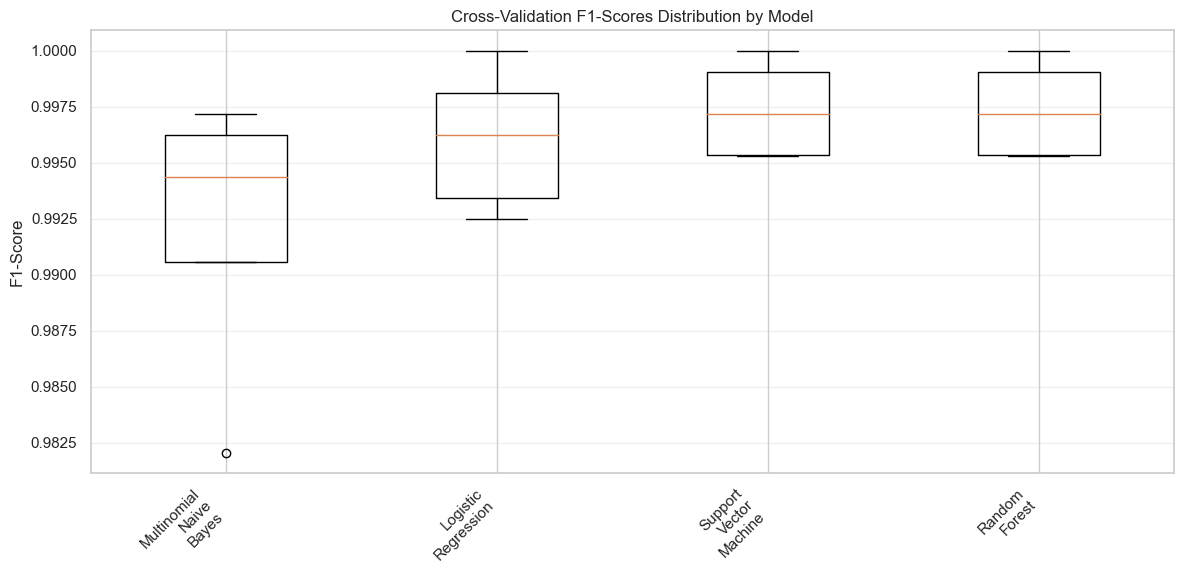


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Random Forest: 0.9974
3. Logistic Regression: 0.9961


In [ ]:
# Initialize stratified K-fold cross-validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store results
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

### 5.2 Hyperparameter Tuning

Optimize the hyperparameters of the top-performing models to achieve better performance.

#### 5.2.1 Optimize Model Settings: Define Hyperparameter Grids

Define hyperparameter grids for the top-performing models based on cross-validation results.

In [ ]:
# Define hyperparameter grids for top models
hyperparameter_grids = {
    'Multinomial Naive Bayes': {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
        'fit_prior': [True, False]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1', 'l2'],
        'max_iter': [1000, 2000]
    },
    'Support Vector Machine': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'loss': ['hinge', 'squared_hinge'],
        'max_iter': [5000, 10000]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Filter grids for only top performing models
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for top models:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for top models:

Support Vector Machine:
  C: [0.01, 0.1, 1.0, 10.0, 100.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000, 10000]

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]

Logistic Regression:
  C: [0.01, 0.1, 1.0, 10.0, 100.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000, 2000]


#### 5.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

Use GridSearchCV to systematically explore different combinations of hyperparameter values.

In [115]:
# Perform grid search for each top model
best_models = {}
grid_search_results = {}

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

for model_name in top_models:
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]
        param_grid = selected_grids[model_name]
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []
            
            # L1 penalty only works with liblinear and saga
            l1_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear'],
                'penalty': ['l1'],
                'max_iter': param_grid['max_iter']
            }
            
            # L2 penalty works with both solvers
            l2_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear', 'lbfgs'],
                'penalty': ['l2'],
                'max_iter': param_grid['max_iter']
            }
            
            # Search L1 grid
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)
            
            # Search L2 grid  
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)
            
            # Select best between L1 and L2
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1
            else:
                grid_search = grid_search_l2
        else:
            # Standard grid search for other models
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)
        
        # Store results
        best_models[model_name] = grid_search.best_estimator_
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_
        }
        
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")

# Summary of hyperparameter tuning results
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],
    'Improvement': [
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))

# Select the best model overall
best_model_name = tuning_summary.iloc[0]['Model']
best_model = best_models[best_model_name]
best_score = tuning_summary.iloc[0]['Best_F1_Score']

print(f"\n🏆 SELECTED BEST MODEL: {best_model_name}")
print(f"   Cross-validation F1-Score: {best_score:.4f}")
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best F1-Score: 0.9955
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Optimizing Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best F1-Score: 0.9955
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Optimizing Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 20 candidates, to

### 5.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Additional Cross-Validation for Best Model: Support Vector Machine
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]


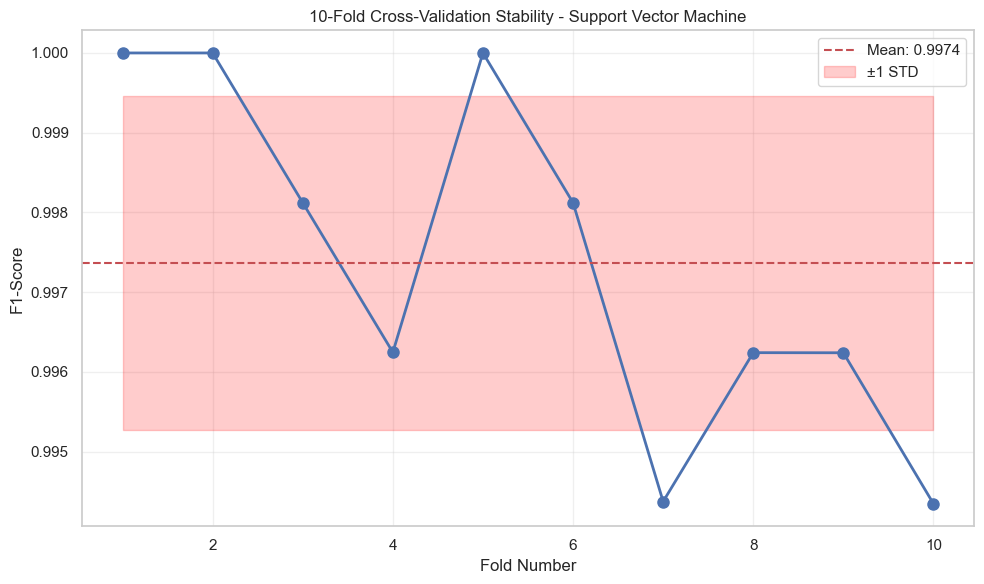


Model Stability Assessment: Stable
Coefficient of Variation: 0.21%


In [116]:
# Perform additional cross-validation on the best model to ensure stability
print(f"Additional Cross-Validation for Best Model: {best_model_name}")
print("="*60)

# Use 10-fold CV for more robust validation
extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
extended_scores = cross_val_score(best_model, X_train_val_tfidf, y_train_val, 
                                 cv=extended_cv, scoring='f1_weighted', n_jobs=-1)

print(f"10-Fold CV F1-Scores: {extended_scores}")
print(f"Mean: {extended_scores.mean():.4f}")
print(f"Standard Deviation: {extended_scores.std():.4f}")
print(f"95% Confidence Interval: [{extended_scores.mean() - 1.96*extended_scores.std():.4f}, "
      f"{extended_scores.mean() + 1.96*extended_scores.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
plt.fill_between(range(1, 11), 
                extended_scores.mean() - extended_scores.std(),
                extended_scores.mean() + extended_scores.std(),
                alpha=0.2, color='red', label='±1 STD')
plt.title(f'10-Fold Cross-Validation Stability - {best_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if model performance is consistent
cv_stability = "Stable" if extended_scores.std() < 0.02 else "Moderate" if extended_scores.std() < 0.05 else "Unstable"
print(f"\nModel Stability Assessment: {cv_stability}")
print(f"Coefficient of Variation: {(extended_scores.std() / extended_scores.mean()) * 100:.2f}%")

### 6. Model Training

Train the selected model with optimized hyperparameters on the complete training dataset.

In [117]:
# Retrain the best model on the full training set with optimized hyperparameters
print(f"Training Selected Model: {best_model_name}")
print("="*50)

# Prepare final training data (combining train and validation sets)
X_final_train = X_train_val_tfidf
y_final_train = y_train_val

# Train the final model
final_model = best_model
final_model.fit(X_final_train, y_final_train)

# Prepare test data
X_test_tfidf_final = tfidf_vectorizer.transform(X_test)

print(f"✓ Model training completed successfully")
print(f"✓ Training data shape: {X_final_train.shape}")
print(f"✓ Test data prepared: {X_test_tfidf_final.shape}")
print(f"✓ Model type: {type(final_model).__name__}")
print(f"✓ Optimized parameters: {grid_search_results[best_model_name]['best_params']}")

# Display model details
if hasattr(final_model, 'feature_log_prob_') and best_model_name == 'Multinomial Naive Bayes':
    print(f"✓ Vocabulary size: {final_model.feature_log_prob_.shape[1]}")
elif hasattr(final_model, 'coef_'):
    print(f"✓ Feature coefficients shape: {final_model.coef_.shape}")

Training Selected Model: Support Vector Machine
✓ Model training completed successfully
✓ Training data shape: (5328, 3235)
✓ Test data prepared: (1333, 3235)
✓ Model type: LinearSVC
✓ Optimized parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
✓ Feature coefficients shape: (25, 3235)
✓ Model training completed successfully
✓ Training data shape: (5328, 3235)
✓ Test data prepared: (1333, 3235)
✓ Model type: LinearSVC
✓ Optimized parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
✓ Feature coefficients shape: (25, 3235)


## 7. Model Evaluation

Comprehensive evaluation of the trained model's performance using multiple metrics and visualization techniques.

### 7.1 Assess Performance: Evaluate Using Multiple Metrics

Calculate accuracy, precision, recall, and F1-score on the test set.

MODEL PERFORMANCE EVALUATION
Selected Model: Support Vector Machine
Test Set Size: 1333 samples
Number of Classes: 25

OVERALL PERFORMANCE METRICS:
------------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

DETAILED CLASSIFICATION REPORT:
----------------------------------------
                    precision    recall  f1-score   support

              Acne     1.0000    1.0000    1.0000        66
         Back pain     1.0000    1.0000    1.0000        52
     Blurry vision     1.0000    1.0000    1.0000        49
   Body feels weak     1.0000    0.9792    0.9895        48
             Cough     1.0000    1.0000    1.0000        59
          Ear ache     1.0000    1.0000    1.0000        54
    Emotional pain     1.0000    1.0000    1.0000        46
      Feeling cold     1.0000    1.0000    1.0000        53
     Feeling dizzy     1.0000    1.0000    1.0000        57
         Foot ache     1.0000    1.0000    1.0000        44
  Hair falling

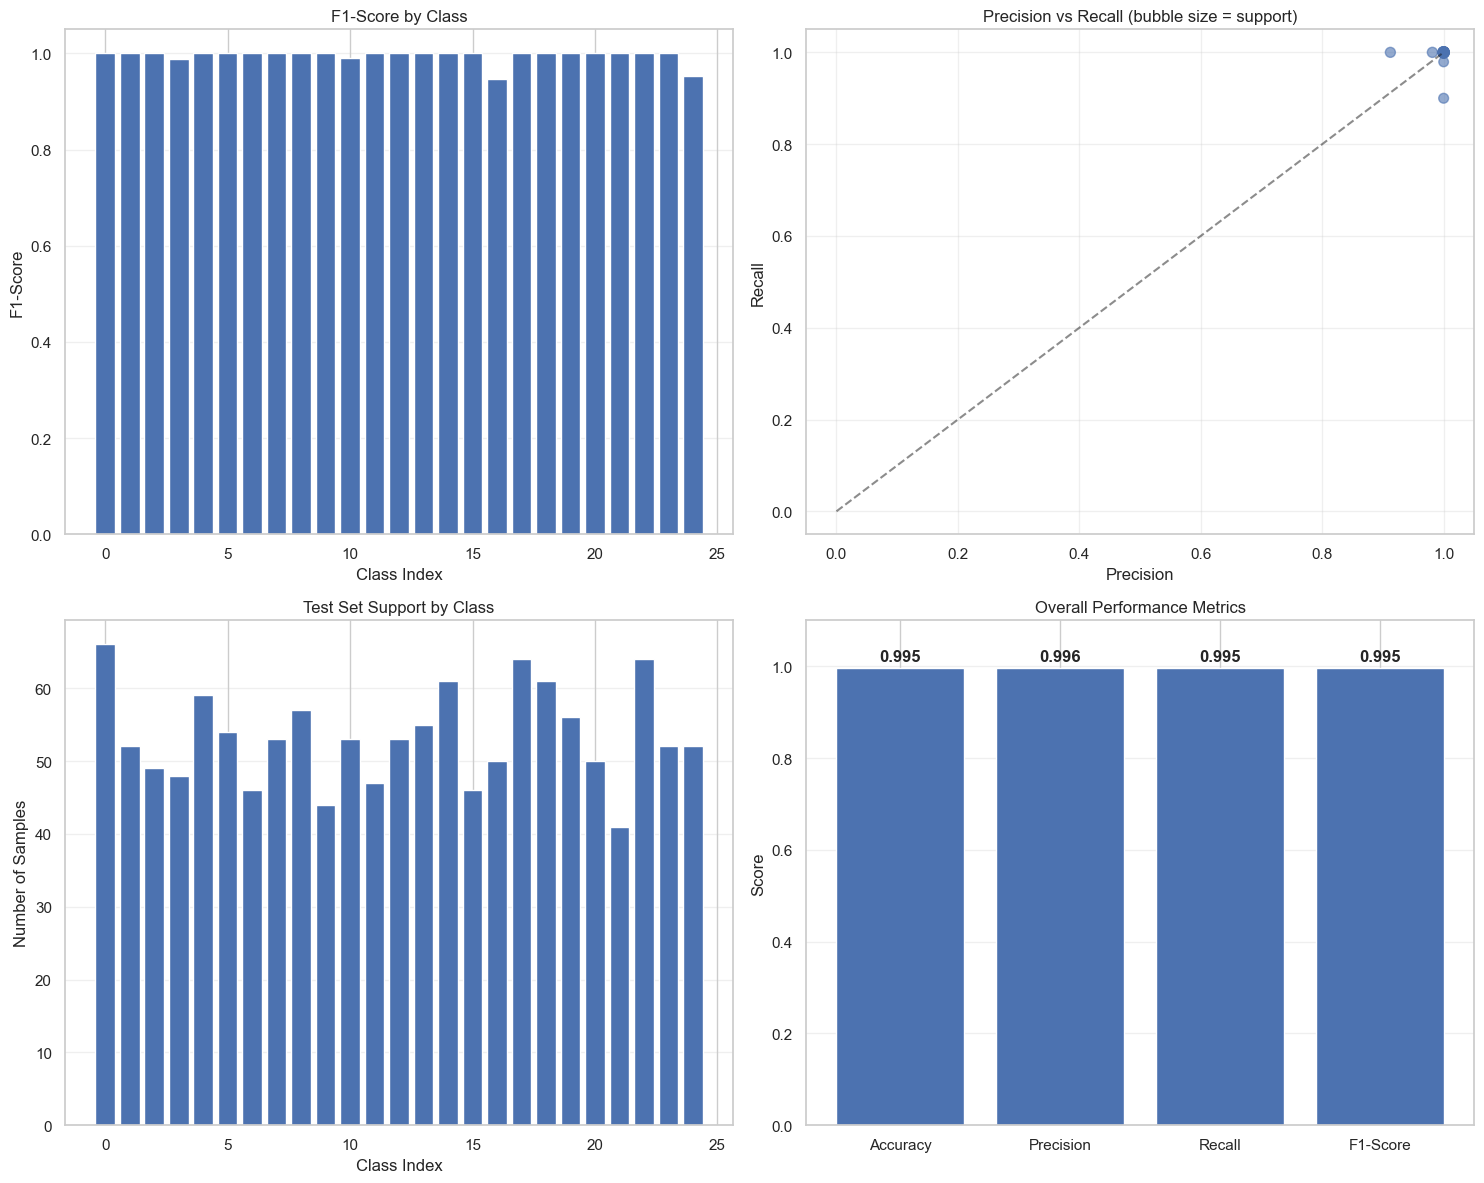

In [ ]:
# Make predictions on test set
y_test_pred = final_model.predict(X_test_tfidf_final)

# Calculate primary metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, test_support = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

# Calculate per-class metrics
precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, zero_division=0
)

print(f"MODEL PERFORMANCE EVALUATION")
print("="*50)
print(f"Selected Model: {best_model_name}")
print(f"Test Set Size: {len(y_test)} samples")
print(f"Number of Classes: {len(np.unique(y_test))}")

print(f"\nOVERALL PERFORMANCE METRICS:")
print("-" * 30)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

# Detailed classification report
print(f"\nDETAILED CLASSIFICATION REPORT:")
print("-" * 40)
class_names = [label_encoder.inverse_transform([i])[0] for i in range(len(label_encoder.classes_))]
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

# Create performance summary DataFrame
performance_summary = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1_Score': f1_per_class,
    'Support': support_per_class
}).round(4)

# Add summary statistics
summary_stats = pd.DataFrame({
    'Class': ['MACRO AVG', 'WEIGHTED AVG'],
    'Precision': [precision_per_class.mean(), test_precision],
    'Recall': [recall_per_class.mean(), test_recall],
    'F1_Score': [f1_per_class.mean(), test_f1],
    'Support': [support_per_class.sum(), support_per_class.sum()]
}).round(4)

performance_summary = pd.concat([performance_summary, summary_stats], ignore_index=True)

print(f"\nPERFORMANCE SUMMARY TABLE:")
print("-" * 30)
print(performance_summary.to_string(index=False))

# Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Per-class F1-scores
axes[0, 0].bar(range(len(f1_per_class)), f1_per_class)
axes[0, 0].set_title('F1-Score by Class')
axes[0, 0].set_xlabel('Class Index')
axes[0, 0].set_ylabel('F1-Score')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Precision vs Recall scatter
axes[0, 1].scatter(precision_per_class, recall_per_class, s=support_per_class, alpha=0.6)
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Precision vs Recall (bubble size = support)')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Support distribution
axes[1, 0].bar(range(len(support_per_class)), support_per_class)
axes[1, 0].set_title('Test Set Support by Class')
axes[1, 0].set_xlabel('Class Index')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Overall metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_accuracy, test_precision, test_recall, test_f1]
bars = axes[1, 1].bar(metrics_names, metrics_values)
axes[1, 1].set_title('Overall Performance Metrics')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix: Analyze Classification Performance Across Classes

Generate and visualize the confusion matrix to understand model performance for each class.

CONFUSION MATRIX ANALYSIS
Matrix dimensions: (25, 25)
Total predictions: 1333
Correct predictions: 1327


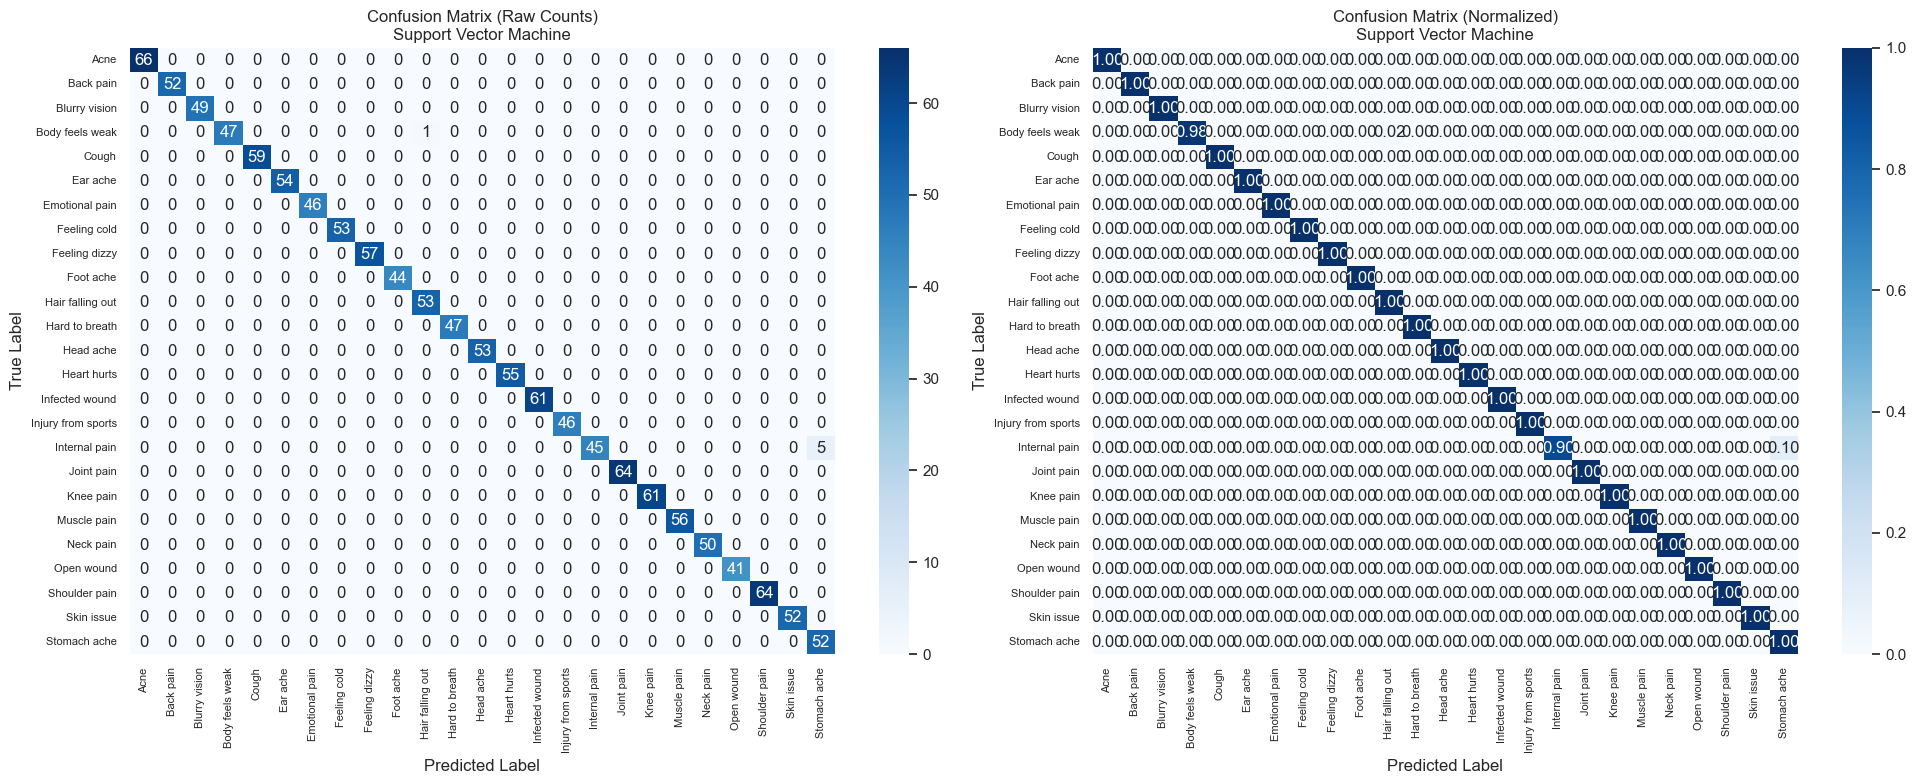


CONFUSION MATRIX STATISTICS:
-----------------------------------
Best performing classes:
  1. Stomach ache: 1.000 accuracy (52 samples)
  2. Skin issue: 1.000 accuracy (52 samples)
  3. Back pain: 1.000 accuracy (52 samples)
  4. Blurry vision: 1.000 accuracy (49 samples)
  5. Cough: 1.000 accuracy (59 samples)

Worst performing classes:
  1. Internal pain: 0.900 accuracy (50 samples)
  2. Body feels weak: 0.979 accuracy (48 samples)
  3. Acne: 1.000 accuracy (66 samples)
  4. Shoulder pain: 1.000 accuracy (64 samples)
  5. Open wound: 1.000 accuracy (41 samples)

MOST COMMON MISCLASSIFICATIONS:
-----------------------------------
  1. Internal pain → Stomach ache: 5 cases
  2. Body feels weak → Hair falling out: 1 cases

OVERALL CONFUSION MATRIX SUMMARY:
----------------------------------------
Total test samples: 1333
Correct predictions: 1327
Misclassifications: 6
Error rate: 0.45%


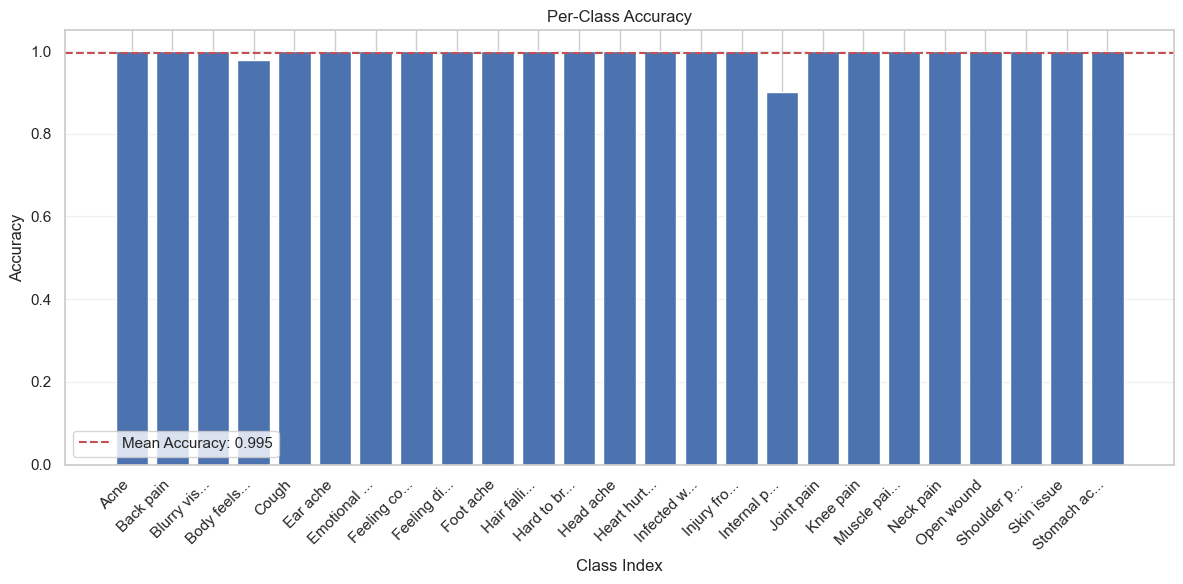

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Calculate normalized confusion matrix
cm_normalized = confusion_matrix(y_test, y_test_pred, normalize='true')

print(f"CONFUSION MATRIX ANALYSIS")
print("="*40)
print(f"Matrix dimensions: {cm.shape}")
print(f"Total predictions: {cm.sum()}")
print(f"Correct predictions: {np.trace(cm)}")

# Create subplots for both raw and normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Confusion Matrix (Raw Counts)\n{best_model_name}')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='both', which='major', labelsize=8)

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
           xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'Confusion Matrix (Normalized)\n{best_model_name}')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.show()

# Analyze confusion matrix statistics
print(f"\nCONFUSION MATRIX STATISTICS:")
print("-" * 35)

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
worst_classes = np.argsort(per_class_accuracy)[:5]  # 5 worst performing classes
best_classes = np.argsort(per_class_accuracy)[-5:]   # 5 best performing classes

print(f"Best performing classes:")
for i, class_idx in enumerate(reversed(best_classes), 1):
    class_name = class_names[class_idx]
    accuracy = per_class_accuracy[class_idx]
    support = cm.sum(axis=1)[class_idx]
    print(f"  {i}. {class_name}: {accuracy:.3f} accuracy ({support} samples)")

print(f"\nWorst performing classes:")
for i, class_idx in enumerate(worst_classes, 1):
    class_name = class_names[class_idx]
    accuracy = per_class_accuracy[class_idx]
    support = cm.sum(axis=1)[class_idx]
    print(f"  {i}. {class_name}: {accuracy:.3f} accuracy ({support} samples)")

# Identify most common misclassifications
print(f"\nMOST COMMON MISCLASSIFICATIONS:")
print("-" * 35)

# Find off-diagonal elements (misclassifications)
misclassification_counts = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            misclassification_counts.append((cm[i, j], class_names[i], class_names[j]))

# Sort by frequency and show top 10
misclassification_counts.sort(reverse=True)
for i, (count, true_class, predicted_class) in enumerate(misclassification_counts[:10], 1):
    print(f"  {i}. {true_class} → {predicted_class}: {count} cases")

# Calculate overall confusion matrix metrics
total_samples = cm.sum()
correct_predictions = np.trace(cm)
total_misclassifications = total_samples - correct_predictions

print(f"\nOVERALL CONFUSION MATRIX SUMMARY:")
print("-" * 40)
print(f"Total test samples: {total_samples}")
print(f"Correct predictions: {correct_predictions}")
print(f"Misclassifications: {total_misclassifications}")
print(f"Error rate: {(total_misclassifications/total_samples)*100:.2f}%")

# Visualize per-class accuracy
plt.figure(figsize=(12, 6))
plt.bar(range(len(per_class_accuracy)), per_class_accuracy)
plt.axhline(y=per_class_accuracy.mean(), color='r', linestyle='--', 
           label=f'Mean Accuracy: {per_class_accuracy.mean():.3f}')
plt.title('Per-Class Accuracy')
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.xticks(range(len(class_names)), [name[:10] + '...' if len(name) > 10 else name 
                                    for name in class_names], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Threshold for Clinical Decision Support: 0.7
Selected Model: Support Vector Machine

FINAL MODEL PERFORMANCE:
-------------------------
Test Accuracy:  0.9955
Test Precision: 0.9958
Test Recall:    0.9955
Test F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.7: ✓ (0.9955)
Precision ≥ 0.7: ✓ (0.9958)
Recall ≥ 0.7: ✓ (0.9955)
F1-Score ≥ 0.7: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

ADDITIONAL INSIGHTS:
--------------------
Cross-validation stability: Stable
Model confidence: 0.0021 standard deviation
Best performing class: Stomach ache (1.000 accuracy)
Most challenging class: Internal pain (0.900 accuracy)


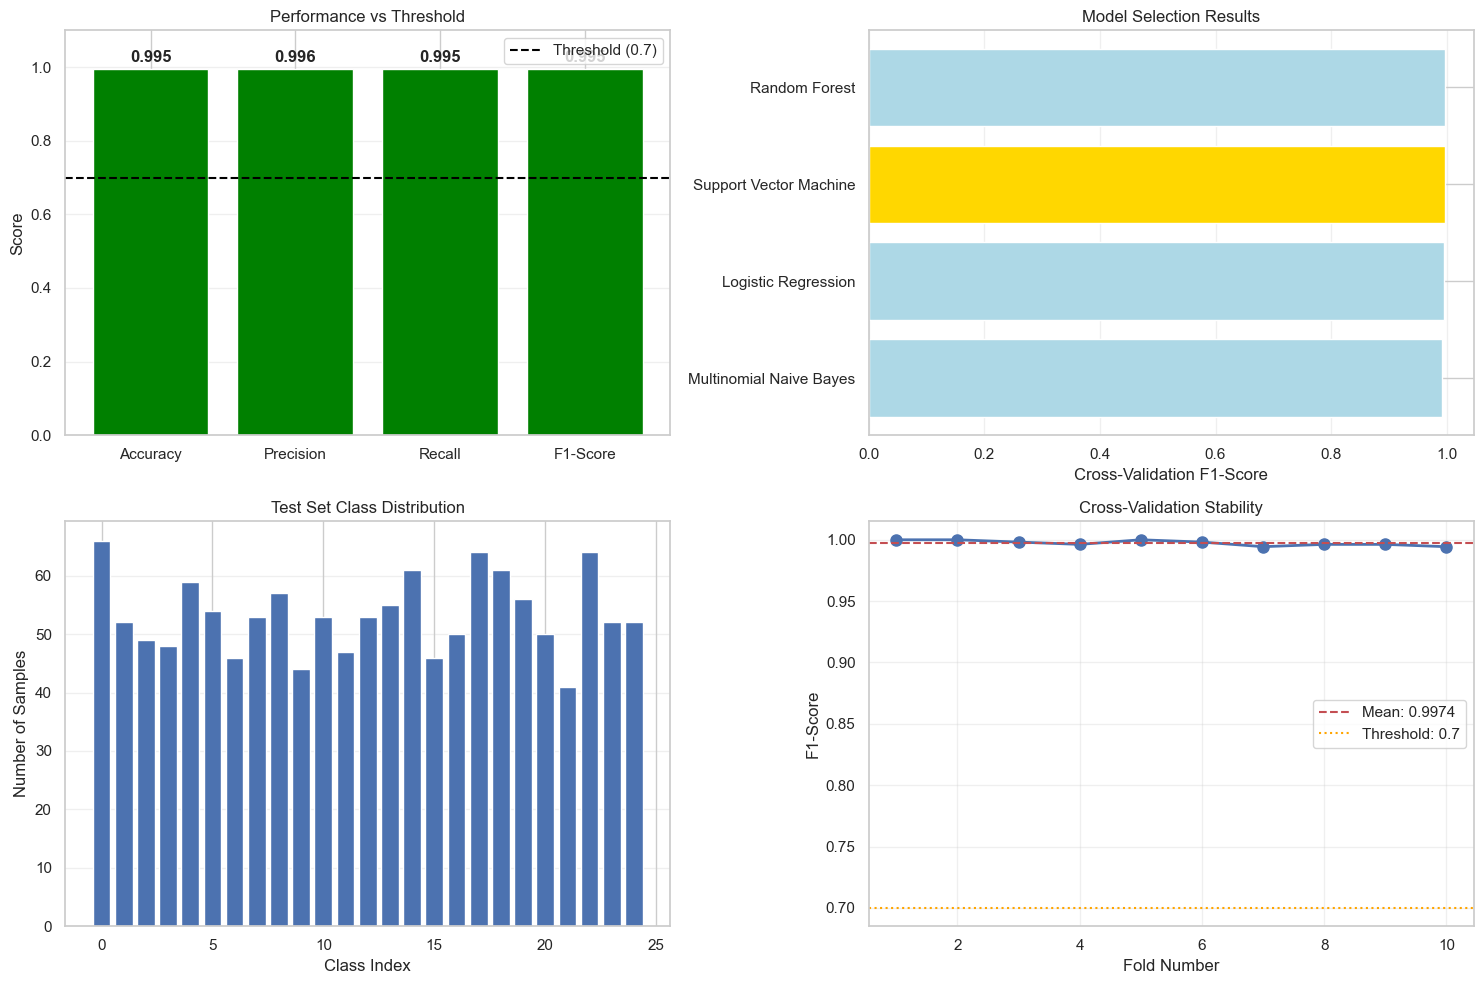


FINAL RESEARCH OUTCOME: ACCEPTED


In [120]:
# Research hypothesis evaluation
performance_threshold = 0.7  # Minimum acceptable performance for clinical decision support

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")
print(f"patient symptoms from text data on the population level?")
print()

print(f"Performance Threshold for Clinical Decision Support: {performance_threshold}")
print(f"Selected Model: {best_model_name}")
print()

print(f"FINAL MODEL PERFORMANCE:")
print("-" * 25)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

# Determine hypothesis outcome
accuracy_sufficient = test_accuracy >= performance_threshold
precision_sufficient = test_precision >= performance_threshold
recall_sufficient = test_recall >= performance_threshold
f1_sufficient = test_f1 >= performance_threshold

overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                         recall_sufficient, f1_sufficient])

print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
print("-" * 35)
print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({test_accuracy:.4f})")
print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({test_precision:.4f})")
print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({test_recall:.4f})")
print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({test_f1:.4f})")

print(f"\nHYPOTHESIS CONCLUSION:")
print("="*25)

if overall_sufficient:
    conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
    conclusion_status = "ACCEPTED"
else:
    conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
    conclusion_status = "REJECTED (H10 accepted)"

print(f"Status: {conclusion_status}")
print(f"Conclusion: {conclusion}")

# Additional analysis
print(f"\nADDITIONAL INSIGHTS:")
print("-" * 20)
print(f"Cross-validation stability: {cv_stability}")
print(f"Model confidence: {extended_scores.std():.4f} standard deviation")
print(f"Best performing class: {class_names[best_classes[-1]]} ({per_class_accuracy[best_classes[-1]]:.3f} accuracy)")
print(f"Most challenging class: {class_names[worst_classes[0]]} ({per_class_accuracy[worst_classes[0]]:.3f} accuracy)")

# Create final summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Threshold comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_accuracy, test_precision, test_recall, test_f1]
colors = ['green' if v >= performance_threshold else 'red' for v in values]

bars = ax1.bar(metrics, values, color=colors)
ax1.axhline(y=performance_threshold, color='black', linestyle='--', 
           label=f'Threshold ({performance_threshold})')
ax1.set_title('Performance vs Threshold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Model comparison (from earlier CV results)
models_cv = list(cv_results.keys())
scores_cv = [cv_results[model]['mean'] for model in models_cv]
colors_models = ['gold' if model == best_model_name else 'lightblue' for model in models_cv]

ax2.barh(models_cv, scores_cv, color=colors_models)
ax2.set_xlabel('Cross-Validation F1-Score')
ax2.set_title('Model Selection Results')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Class distribution in test set
class_counts = np.bincount(y_test)
ax3.bar(range(len(class_counts)), class_counts)
ax3.set_title('Test Set Class Distribution')
ax3.set_xlabel('Class Index')
ax3.set_ylabel('Number of Samples')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Performance over CV folds
ax4.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
ax4.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
ax4.axhline(y=performance_threshold, color='orange', linestyle=':', 
           label=f'Threshold: {performance_threshold}')
ax4.set_title('Cross-Validation Stability')
ax4.set_xlabel('Fold Number')
ax4.set_ylabel('F1-Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
print(f"{'='*60}")